False


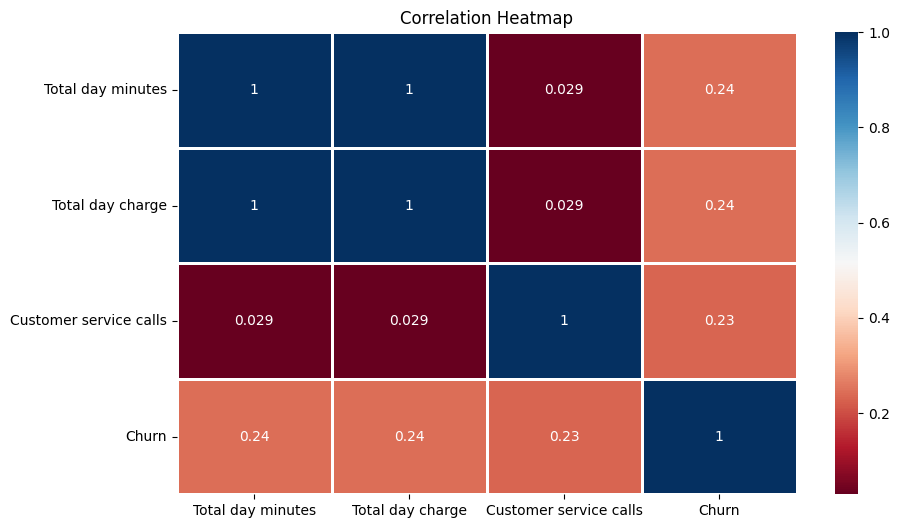

<Figure size 640x480 with 0 Axes>

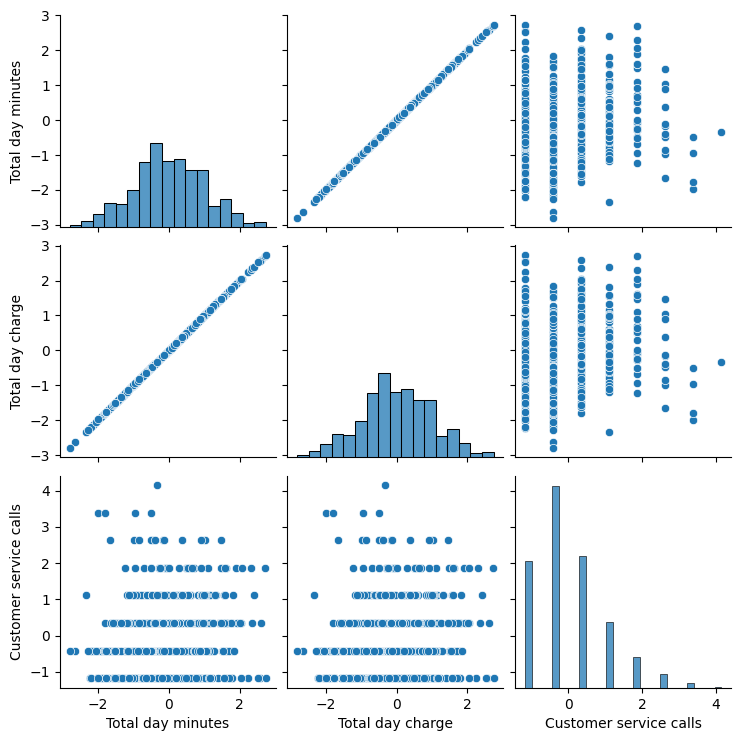

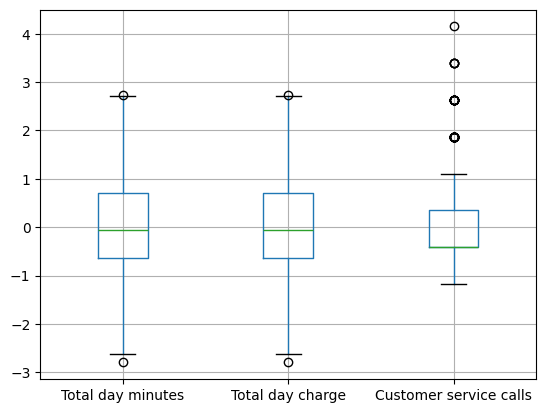

[[113   2]
 [ 10   9]]
              precision    recall  f1-score   support

       False       0.92      0.98      0.95       115
        True       0.82      0.47      0.60        19

    accuracy                           0.91       134
   macro avg       0.87      0.73      0.77       134
weighted avg       0.90      0.91      0.90       134

Accuracy of our model is 91.04 %.


<Figure size 640x480 with 0 Axes>

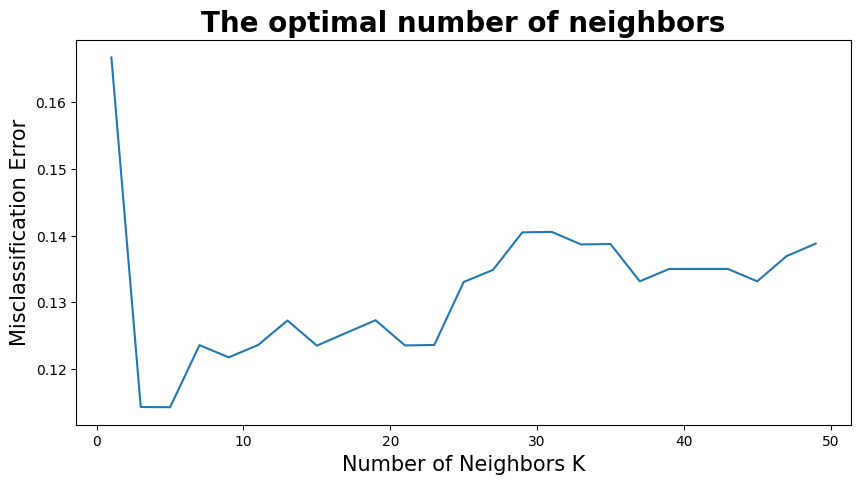

The optimal number of neighbors is 5.


In [ ]:
#Import all libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


#Read Churn file into a variable called data
data = pd.read_csv('/content/Churn.csv')

#Checking for missing values
print(data.isnull().any().any())

#Display first few lines of data
data.head()

#Select only the columns from the original dataset that have a significant impact on our dependent variable
data_clean = data.filter(['Total day minutes','Total day charge', 'Customer service calls','Churn'])

#Separating the independent variables as features for training model
feat_columns = ['Total day minutes','Total day charge','Customer service calls']

##Creating Independent (X) and Dependent(y) variables for test/training
X = data_clean[feat_columns].values
y= data_clean['Churn']

#plot a figure 15in by 9 inches
plt.figure(figsize=(10,6))

#draws heatmap with dataframe as input to correlate all the columns in the dataframe
sns.heatmap(data_clean.corr().abs(), annot=True, cmap='RdBu', linewidth = 1,)

#title the plot and display
plt.title('Correlation Heatmap')
plt.show()

#Importing libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

# Split the data into to two sets one for training (80%) and one for testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state=11, stratify=y)

#Use standard scaler model to make the training data uniform
scaler = StandardScaler()
scaler.fit(X_train)

#Transforming the train/test data into a standard form
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Calling learning model to make classifications based on proximity of data to each other
classifier = KNeighborsClassifier(n_neighbors=5)

# Fitting the model to the data
classifier.fit(X_train, y_train)

#dataframe created to plot the new trained and transformed data
lastX= pd.DataFrame(X_train, columns=['Total day minutes','Total day charge','Customer service calls'])

# Predicting the Test set results
y_pred = classifier.predict(X_test)

#Creating a pairplot showing the relationships between variables after transforming the data
plt.figure()
sns.pairplot(lastX)
plt.show()

#Creating a Boxplot showing the relationship of the data and any outliers after tranforming the data
plt.figure()
lastX.boxplot(figsize=(20, 15))
plt.show()

#create and display a Confusion matrix showing how much error in our model
cm = confusion_matrix(y_test,y_pred)
print(cm)

#create and display a Classification report providing more detail aboout the accuracy of our model
cr = classification_report(y_test,y_pred)
print(cr)

#Displaying the accuracy as a percentage
accuracy = accuracy_score(y_test, y_pred)*100
print('Accuracy of our model is ' + str(round(accuracy, 2)) + ' %.')

"""This model provided the highest accuracy and lowest number of false positives."""

# creating list of K for KNN
k_list = list(range(1,50,2))
# creating list of cv scores
cv_scores = []

# perform 10-fold cross validation to test the model's prediction ability
for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

# calculating misclassification error to see how often the predictions were wrong
MSE = [1 - x for x in cv_scores]

#plot the graph, size, title, label x & y and display
plt.figure()
plt.figure(figsize=(10,5))
plt.title('The optimal number of neighbors', fontsize=20, fontweight='bold')
plt.xlabel('Number of Neighbors K', fontsize=15)
plt.ylabel('Misclassification Error', fontsize=15)
sns.set_style("whitegrid")
plt.plot(k_list, MSE)

plt.show()

# finding best k value to ensure we have used the best possible model for accuracy
best_k = k_list[MSE.index(min(MSE))]
print("The optimal number of neighbors is %d." % best_k)

